# Início - Projeto Final - PGC201 Mineração de Dados (PPGCO/UFU)

# Bank Marketing - Classificação

> **Objetivo:** prever se um cliente de um banco português irá aderir a um depósito a prazo (tipo CDB) com base em atributos demográficos, de campanha e socioeconômicos

> **Dataset:** [Bank Marketing - UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

> **Referência:** [Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22-31.](https://doi.org/10.1016/j.dss.2014.03.001)

> **Versão:** `bank-additional-full.csv` (41.188 instâncias, 20 features + target)

---

# Configurações

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

# import warnings
# warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# --- métricas ---
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    make_scorer
)

In [5]:
# --- validação cruzada ---
from sklearn.model_selection import (
    cross_val_score, cross_validate, StratifiedKFold, GridSearchCV
)

In [6]:
# --- tema visual ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [7]:
# --- classificadores ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [8]:
# --- carregar artefatos ---
import os, time, json, joblib

In [9]:
SEED = 42

42

---

# Roadmap

Objetivo: prever se um cliente subscreveu depósito a prazo (`y`) usando os 5 classificadores da disciplina

| Etapa | Descrição |
|---|---|
| 1 | Setup + carregar artefatos da análise |
| 2 | Baseline: todos os modelos com hiperparâmetros default + CV 5-fold |
| 3 | Diagnóstico: overfitting, matrizes de confusão, curvas ROC |
| 4 | Tuning de hiperparâmetros (GridSearchCV no treino, seleção no val) |
| 5 | Avaliação final no conjunto de teste |
| 6 | Comparação estatística entre modelos (McNemar) |
| 7 | Análise do melhor modelo (importância, calibração) |

Métricas primárias: F1-score e ROC-AUC (dataset desbalanceado 88/12 - acurácia é enganosa)

---

# Carregando Artefatos

In [10]:
X_train = pd.read_csv("artifacts/X_train_sel.csv", index_col=0)
X_val   = pd.read_csv("artifacts/X_val_sel.csv",   index_col=0)
X_test  = pd.read_csv("artifacts/X_test_sel.csv",  index_col=0)

y_train = pd.read_csv("artifacts/y_train.csv", index_col=0).squeeze()
y_val   = pd.read_csv("artifacts/y_val.csv",   index_col=0).squeeze()
y_test  = pd.read_csv("artifacts/y_test.csv",  index_col=0).squeeze()

with open("artifacts/metadata.json") as f:
    meta = json.load(f)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Proporção positiva - train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")
print(f"Features: {X_train.columns.tolist()}")

Train: (28829, 9) | Val: (6180, 9) | Test: (6179, 9)
Proporção positiva - train: 11.27% | val: 11.26% | test: 11.26%
Features: ['age', 'cons.conf.idx', 'cons.price.idx', 'emp.var.rate', 'euribor3m', 'nr.employed', 'poutcome_success', 'previous', 'was_contacted']


---

# Baseline

Treinamos os 5 classificadores com parâmetros default do `sklearn`, avaliados por \
Stratified 5-Fold CV no conjunto de treino. O objetivo não é obter o melhor resultado, \
por enquanto é estabelecer uma referência para quantificar o atingido pelo tuning

Comparamos **scores de treino vs teste do CV** para diagnosticar overfitting: \
se o score de treino é muito superior ao de teste, o modelo está memorizando ao invés de generalizar.

Por que F1 e AUC em vez de acurácia? Com desbalanceamento 88/12, um modelo que prevê sempre \
"no" atinge 88% de acurácia sem aprender nada. O F1 penaliza modelos que ignoram a classe minoritária, \
e o AUC mede a capacidade de ranquear positivos acima de negativos independente do threshold.

## Modelos

In [11]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "KNN":           KNeighborsClassifier(),
    "Naive Bayes":   GaussianNB(),
    "SVM (RBF)":     SVC(kernel="rbf", probability=True, random_state=SEED),
    "MLP":           MLPClassifier(max_iter=1000, random_state=SEED),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy":  "accuracy",
    "f1":        "f1",
    "precision": "precision",
    "recall":    "recall",
    "roc_auc":   "roc_auc",
};

## Treino

In [12]:
results = {}
for name, model in models.items():
    t0 = time.time()
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    elapsed = time.time() - t0
    results[name] = scores
    
    f1_train = scores["train_f1"].mean()
    f1_test  = scores["test_f1"].mean()
    auc_test = scores["test_roc_auc"].mean()
    print(f"{name:>15} | F1 treino: {f1_train:.4f} | "
          f"F1 CV: {f1_test:.4f} | AUC CV: {auc_test:.4f} | "
          f"Overfit gap: {f1_train - f1_test:+.4f} | {elapsed:.1f}s")

  Decision Tree | F1 treino: 0.6908 | F1 CV: 0.3561 | AUC CV: 0.6061 | Overfit gap: +0.3347 | 3.4s
            KNN | F1 treino: 0.4852 | F1 CV: 0.3590 | AUC CV: 0.7235 | Overfit gap: +0.1262 | 3.2s
    Naive Bayes | F1 treino: 0.4135 | F1 CV: 0.4145 | AUC CV: 0.7521 | Overfit gap: -0.0010 | 0.2s
      SVM (RBF) | F1 treino: 0.3249 | F1 CV: 0.3125 | AUC CV: 0.6552 | Overfit gap: +0.0124 | 91.5s
            MLP | F1 treino: 0.3351 | F1 CV: 0.3211 | AUC CV: 0.7898 | Overfit gap: +0.0141 | 6.2s


## Tabela Comparação

In [13]:
rows = []
for name, scores in results.items():
    rows.append({
        "Modelo": name,
        "Acurácia (CV)":  scores["test_accuracy"].mean(),
        "Precisão (CV)": scores["test_precision"].mean(),
        "Recall (CV)":  scores["test_recall"].mean(),
        "F1 (Treino)": scores["train_f1"].mean(),
        "F1 (CV)":   scores["test_f1"].mean(),
        "Overfit ΔF1": scores["train_f1"].mean() - scores["test_f1"].mean(),
        "AUC (CV)":  scores["test_roc_auc"].mean(),
    })

baseline_df = pd.DataFrame(rows).set_index("Modelo").sort_values("F1 (CV)", ascending=True)

,Acurácia (CV),Precisão (CV),Recall (CV),F1 (Treino),F1 (CV),Overfit ΔF1,AUC (CV)
Modelo,,,,,,,
SVM (RBF),0.8995,0.6795,0.2032,0.3249,0.3125,0.0124,0.6552
MLP,0.8991,0.6658,0.2121,0.3351,0.3211,0.0141,0.7898
Decision Tree,0.8845,0.4793,0.2839,0.6908,0.3561,0.3347,0.6061
KNN,0.8880,0.5048,0.2786,0.4852,0.3590,0.1262,0.7235
Naive Bayes,0.8762,0.4432,0.3898,0.4135,0.4145,-0.0010,0.7521


In [32]:
baseline_df.to_csv("artifacts/df_baseline_comparativo.csv", index=True)

## Boxplot Comparação

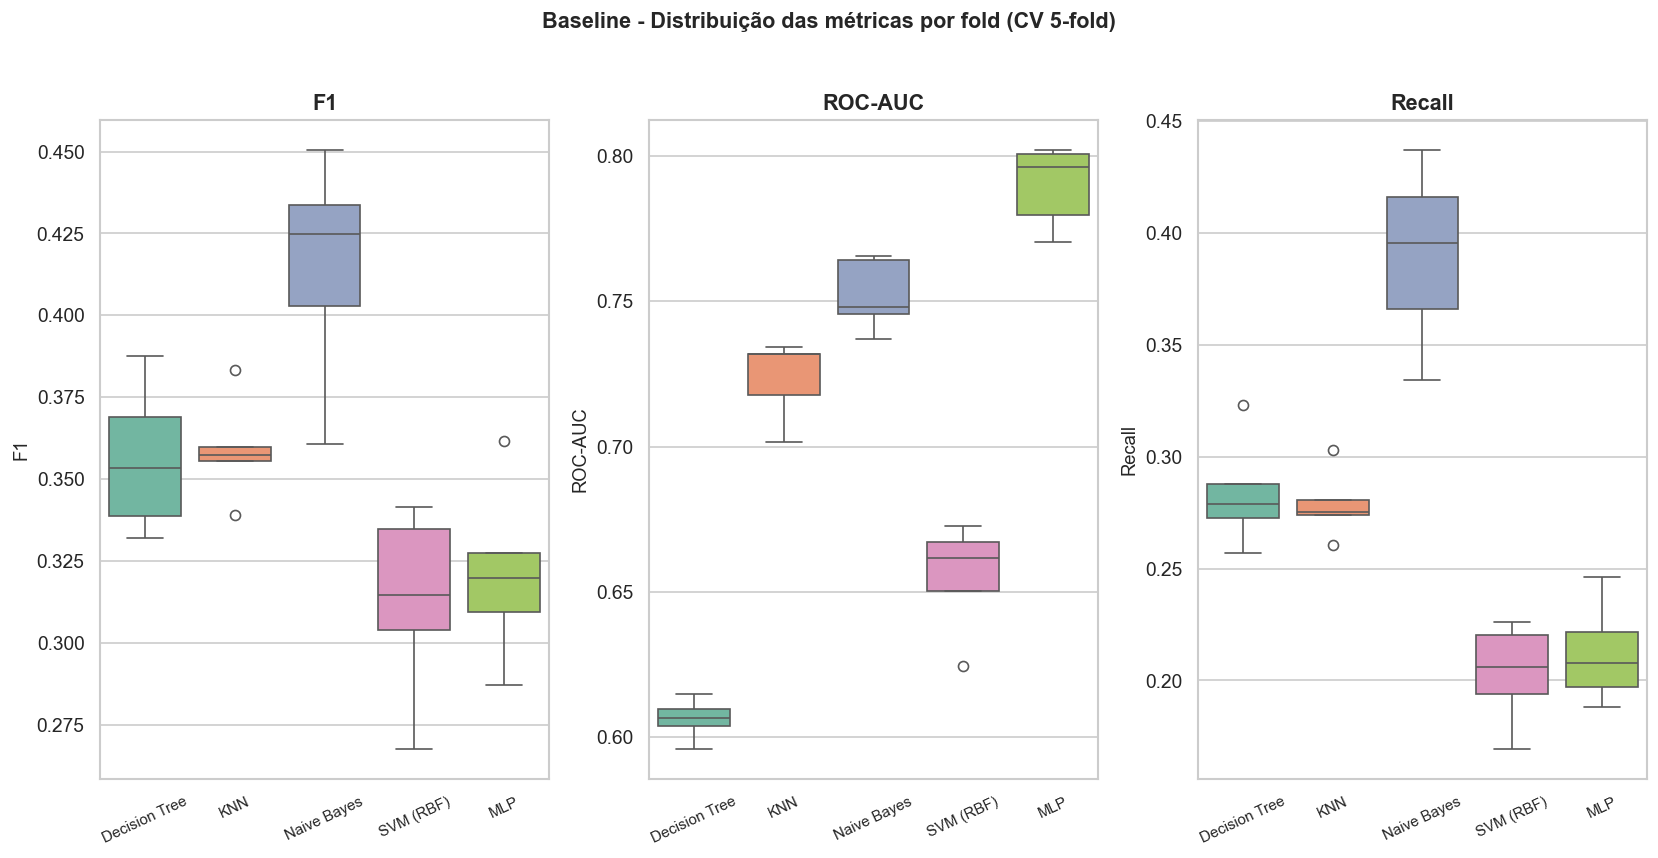

In [14]:
# --- preparar dados para boxplot ---
cv_records = []
for name, scores in results.items():
    for fold_idx in range(cv.n_splits):
        cv_records.append({
            "Modelo": name,
            "F1": scores["test_f1"][fold_idx],
            "ROC-AUC": scores["test_roc_auc"][fold_idx],
            "Recall": scores["test_recall"][fold_idx],
        })
cv_df = pd.DataFrame(cv_records)

fig, axes = plt.subplots(1, 3, figsize=(14, 7))
fig.suptitle("Baseline - Distribuição das métricas por fold (CV 5-fold)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, metric in zip(axes, ["F1", "ROC-AUC", "Recall"]):
    sns.boxplot(data=cv_df, x="Modelo", y=metric, ax=ax, hue="Modelo", palette="Set2", legend=False)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25, labelsize=9)

plt.tight_layout()
fig.savefig("figures/clf_baseline_cv.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagnóstico do Baseline

| Modelo | Recall CV | F1 CV | AUC CV | Overfit ΔF1 | Diagnóstico |
|---|---|---|---|---|---|
| Naive Bayes | **0.3898** | **0.4145** | 0.7521 | -0.001 | Melhor F1 baseline por ter o maior recall (0.3898). Zero overfit. Limitado pela suposição de independência. |
| KNN | 0.2786 | 0.3590 | 0.7235 | +0.126 | Overfit moderado: modelo memoriza vizinhos do treino. Tuning de `k` e `weights` deve ajudar. |
| Decision Tree | 0.2839 | 0.3561 | 0.6061 | **+0.335** | Overfit severo (F1 treino 0.69 vs teste 0.36). Árvore sem poda memoriza o treino. Necessita `max_depth` e `min_samples_leaf`. |
| MLP | 0.2121 | 0.3211 | **0.7898** | +0.014 | Melhor AUC - bom poder de ranking, mas threshold 0.5 gera baixo recall (0.21). Tunável. |
| SVM (RBF) | 0.2032 | 0.3125 | 0.6552 | +0.012 | Pouco overfit, mas AUC baixo. Defaults (`C=1`, `gamma=scale`) provavelmente subótimos. SVM sensível a `C` e `gamma`. |

> Nota: os modelos com maior AUC (MLP, NB) têm bom poder discriminativo mas threshold inadequado. \
Modelos com melhor F1 (NB) sacrificam menos recall. A otimização de threshold pós-tuning será importante.

---

# Tuning de Hiperparâmetros

Usamos `GridSearchCV` com **CV 5-fold estratificado no treino**, otimizando pelo **F1-score**. \
Incluímos `class_weight="balanced"` onde disponível para compensar o desbalanceamento 88/12.

Dois modelos extras são adicionados para comparação (não consegui ficar sem *Deep Learning*:
- **Deep MLP**: rede neural mais profunda (3 camadas) com early stopping
- **TabNet**: arquitetura de deep learning específica para dados tabulares [(Arik & Pfister, 2021)](https://doi.org/10.1609/aaai.v35i8.16826)

In [15]:
param_grids = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=SEED),
        {
            "max_depth": [3, 5, 7, 10, None],
            "min_samples_leaf": [1, 5, 10, 20],
            "class_weight": [None, "balanced"],
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 11, 15, 21],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"],
        }
    ),
    "Naive Bayes": (
        GaussianNB(),
        {
            "var_smoothing": np.logspace(-10, -5, 12),
        }
    ),
    "SVM (RBF)": (
        SVC(kernel="rbf", probability=True, random_state=SEED),
        {
            "C": [0.1, 1, 10, 100],
            "gamma": ["scale", 0.01, 0.1],
            "class_weight": [None, "balanced"],
        }
    ),
    "MLP": (
        MLPClassifier(max_iter=1000, random_state=SEED),
        {
            "hidden_layer_sizes": [(100,), (100, 50), (200, 100)],
            "alpha": [0.0001, 0.001, 0.01],
            "learning_rate_init": [0.001, 0.01],
        }
    ),
};

## Grid Search

In [17]:
tuned = {}
for name, (estimator, params) in param_grids.items():
    t0 = time.time()
    grid = GridSearchCV(
        estimator, params,
        cv=cv, scoring="f1",
        refit=True, n_jobs=-1
    )
    grid.fit(X_train, y_train)
    elapsed = time.time() - t0

    tuned[name] = {
        "model": grid.best_estimator_,
        "best_f1_cv": grid.best_score_,
        "best_params": grid.best_params_,
    }
    print(f"{name:>15} | Best F1 CV: {grid.best_score_:.4f} | {elapsed:>6.1f}s")
    print(f"{'':>15}   {grid.best_params_}")
    print()

  Decision Tree | Best F1 CV: 0.4706 |    5.8s
                  {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 10}

            KNN | Best F1 CV: 0.3690 |    5.4s
                  {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'distance'}

    Naive Bayes | Best F1 CV: 0.4145 |    0.4s
                  {'var_smoothing': np.float64(1e-10)}



C:\Users\Windows 11\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


      SVM (RBF) | Best F1 CV: 0.4689 | 5265.9s
                  {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}

            MLP | Best F1 CV: 0.3451 |  142.1s
                  {'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}



## Modelo Extra 1 - Deep MLP

In [18]:
deep_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=256,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=SEED,
)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'adaptive'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True.",0.15
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For sma

In [19]:
deep_scores = cross_validate(
    deep_mlp, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=-1
)

deep_f1  = deep_scores["test_f1"].mean()
deep_auc = deep_scores["test_roc_auc"].mean()
print(f"Deep MLP | F1 CV: {deep_f1:.4f} | AUC CV: {deep_auc:.4f}")

Deep MLP | F1 CV: 0.3212 | AUC CV: 0.7857


In [20]:
# retreinar no treino completo pra manter consistência
deep_mlp.fit(X_train, y_train)
tuned["Deep MLP"] = {
    "model": deep_mlp,
    "best_f1_cv": deep_f1,
    "best_params": {"hidden_layer_sizes": (256, 128, 64), "alpha": 0.001,
                    "early_stopping": True, "learning_rate": "adaptive"},
}

## Modelo Extra 2 - TabNet

In [23]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=4,
    gamma=1.5, lambda_sparse=1e-3,
    optimizer_params={"lr": 2e-2},
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=__import__("torch.optim.lr_scheduler", fromlist=["StepLR"]).StepLR,
    seed=SEED, verbose=0,
)

,n_d,16
,n_a,16
,n_steps,4
,gamma,1.5
,cat_idxs,[]
,cat_dims,[]
,cat_emb_dim,[]
,seed,42
,verbose,0
,optimizer_params,{'lr': 0.02}
,scheduler_fn,<class 'torch...duler.StepLR'>


In [24]:
tabnet.fit(
    X_train.values, y_train.values,
    eval_set=[(X_val.values, y_val.values)],
    eval_metric=["auc"],
    max_epochs=100, patience=15,
    batch_size=256, drop_last=False,
)

# avaliar por CV manual (TabNet não suporta cross_validate do sklearn)
y_val_pred = tabnet.predict(X_val.values)
y_val_prob = tabnet.predict_proba(X_val.values)[:, 1]
tab_f1  = f1_score(y_val, y_val_pred)
tab_auc = roc_auc_score(y_val, y_val_prob);


Early stopping occurred at epoch 27 with best_epoch = 12 and best_val_0_auc = 0.77807


C:\Users\Windows 11\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [25]:
print(f"TabNet | F1 val: {tab_f1:.4f} | AUC val: {tab_auc:.4f}")
tuned["TabNet"] = {
    "model": tabnet,
    "best_f1_cv": tab_f1,
    "best_params": "n_d=16, n_a=16, n_steps=4",
}

TabNet | F1 val: 0.2726 | AUC val: 0.7781


## Baseline x Tunado

In [33]:
comparison_rows = []
for name in tuned:
    baseline_f1  = results.get(name, {}).get("test_f1", np.array([np.nan])).mean()
    baseline_auc = results.get(name, {}).get("test_roc_auc", np.array([np.nan])).mean()
    tuned_f1  = tuned[name]["best_f1_cv"]

    comparison_rows.append({
        "Modelo": name,
        "F1 baseline": baseline_f1,
        "F1 tunado": tuned_f1,
        "Ganho F1": tuned_f1 - baseline_f1 if not np.isnan(baseline_f1) else np.nan,
        "Params": str(tuned[name]["best_params"]),
    })

comp_df = pd.DataFrame(comparison_rows).set_index("Modelo").sort_values("F1 tunado", ascending=True)

,F1 baseline,F1 tunado,Ganho F1,Params
Modelo,,,,
TabNet,NaN,0.2726,NaN,"n_d=16, n_a=16, n_steps=4"
Deep MLP,NaN,0.3212,NaN,"{'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.001, '..."
MLP,0.3211,0.3451,0.0240,"{'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'lear..."
KNN,0.3590,0.3690,0.0100,"{'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'd..."
Naive Bayes,0.4145,0.4145,0.0000,{'var_smoothing': np.float64(1e-10)}
SVM (RBF),0.3125,0.4689,0.1564,"{'C': 1, 'class_weight': 'balanced', 'gamma': 'scale'}"
Decision Tree,0.3561,0.4706,0.1145,"{'class_weight': 'balanced', 'max_depth': 7, 'min_sample..."


In [34]:
comp_df.to_csv("artifacts/df_tuned_comparativo.csv", index=True)

## Considerações sobre o Tuning

1. Decision Tree ($F1 = 0.471$) e o SVM balanced ($F1 = 0.469$) são os melhores

2. O ganho do SVM ($+0.156$) veio quase inteiramente do `class_weight="balanced"`, ajusta os pesos das classes na função de perda \
$\uparrow$ Errar um "Yes" agora custa ~7x mais que errar um "No" (proporcional a 88/12). Fator mais impactante, que nos trouxe retornos.

3. O Deep MLP ($0.321$) e o TabNet ($0.273$) performaram pior que o MLP básico. \
$\uparrow$ Com apenas 11 features, uma rede `(256,128,64)` tem ~43K parâmetros - overparameterizado demais para o sinal disponível. \
$\uparrow$ TabNet foi projetado para datasets com muitas features e mais dados. Ambos sofrem do mesmo fenômeno: complexidade excessiva.

## Insistindo mais ainda - XGBoost

Pra dados tabulares, costuma ser a mais potente.

In [37]:
from xgboost import XGBClassifier

In [38]:
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # compensa desbalanceamento
    eval_metric="aucpr",
    random_state=SEED, n_jobs=-1, verbosity=0,
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [39]:
xgb_scores = cross_validate(
    xgb_model, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=-1
)
print(f"XGBoost | F1 CV: {xgb_scores['test_f1'].mean():.4f} | "
      f"AUC CV: {xgb_scores['test_roc_auc'].mean():.4f}")

XGBoost | F1 CV: 0.4496 | AUC CV: 0.7803


In [40]:
xgb_model.fit(X_train, y_train)
tuned["XGBoost"] = {
    "model": xgb_model,
    "best_f1_cv": xgb_scores["test_f1"].mean(),
    "best_params": "n_estimators=300, max_depth=5, scale_pos_weight=auto",
}

---

# Avaliação no _Validation_ + Otimização Threshold

O threshold padrão (de classificação mesmo) de 0.5 assume classes equilibradas (50/50). \
Com 88/12 de desbalanceamento, o threshold ótimo tende a ser menor, pois deve permitir \
que o modelo "arrisque" mais previsões positivas - aumentando o recall sem prejudicar a precisão.

> Relembrando: recall = proporção de todos os positivos que capturamos \
precisão = a proporção do que digo que é positivo que realmente o é

O threshold ótimo ($\theta^*$) é encontrado no **conjunto de validação** (nunca no teste) \
percorrendo a curva precision-recall e maximizando:

$$F_1(\theta) = \frac{2 \cdot P(\theta) \cdot R(\theta)}{P(\theta) + R(\theta)}$$

In [79]:
from pprint import pprint
pprint(tuned)

{'Decision Tree': {'best_f1_cv': np.float64(0.4705834833876681),
                   'best_params': {'class_weight': 'balanced',
                                   'max_depth': 7,
                                   'min_samples_leaf': 10},
                   'model': DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                       min_samples_leaf=10, random_state=42)},
 'Deep MLP': {'best_f1_cv': np.float64(0.32123849078217603),
              'best_params': {'alpha': 0.001,
                              'early_stopping': True,
                              'hidden_layer_sizes': (256, 128, 64),
                              'learning_rate': 'adaptive'},
              'model': MLPClassifier(alpha=0.001, batch_size=256, early_stopping=True,
              hidden_layer_sizes=(256, 128, 64), learning_rate='adaptive',
              max_iter=500, random_state=42, validation_fraction=0.15)},
 'KNN': {'best_f1_cv': np.float64(0.3690050562185963),
         'best_params': {'metr

In [85]:
val_results = []
best_models = {}

for name, info in tuned.items(): # `tuned` é o dict de (modelo, params)
    model = info["model"]

    # TabNet requer numpy; sklearn aceita ambos
    X_in = X_val.values if "TabNet" in name else X_val

    # --- obter probabilidades ---
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_in)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_in)
    else:
        y_prob = model.predict(X_in)

    # --- F1 com threshold padrão 0.5 ---
    y_pred_05 = (y_prob >= 0.5).astype(int)
    f1_default = f1_score(y_val, y_pred_05)

    # --- threshold ótimo: percorre a curva PR e maximiza F1 ---
    prec_arr, rec_arr, thr_arr = precision_recall_curve(y_val, y_prob)
    f1_arr = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-8) # evitar divisão por zero
    best_idx = np.argmax(f1_arr)
    best_thr = thr_arr[best_idx] if best_idx < len(thr_arr) else 0.5
    f1_opt   = f1_arr[best_idx]

    y_pred_opt = (y_prob >= best_thr).astype(int)
    auc_val = roc_auc_score(y_val, y_prob)

    val_results.append({
        "Modelo": name,
        "F1 (θ=0.5)":   f1_default,
        "F1 (θ ótimo)":  f1_opt,
        "θ ótimo":       best_thr,
        "AUC val":       auc_val,
        "Precisão (θ ótimo)":  precision_score(y_val, y_pred_opt, zero_division=0),
        "Recall (θ ótimo)":   recall_score(y_val, y_pred_opt),
    })

    best_models[name] = {
        "model": model,
        "threshold": best_thr,
        "y_prob_val": y_prob,
    }

val_df = pd.DataFrame(val_results).set_index("Modelo").sort_values("F1 (θ ótimo)", ascending=True)

,F1 (θ=0.5),F1 (θ ótimo),θ ótimo,AUC val,Precisão (θ ótimo),Recall (θ ótimo)
Modelo,,,,,,
Naive Bayes,0.4018,0.4118,0.3215,0.7485,0.4127,0.4109
KNN,0.3541,0.4127,0.2513,0.6925,0.4047,0.4210
SVM (RBF),0.0000,0.4559,0.2110,0.7639,0.3742,0.5833
XGBoost,0.4368,0.4654,0.6506,0.7658,0.4201,0.5216
TabNet,0.2726,0.4655,0.1683,0.7781,0.4365,0.4986
Deep MLP,0.2851,0.4762,0.2355,0.7810,0.4312,0.5316
Decision Tree,0.4603,0.4774,0.6632,0.7673,0.4241,0.5460
MLP,0.3230,0.4832,0.2218,0.7754,0.4381,0.5388


In [51]:
val_df.to_csv("artifacts/df_val_comparativo.csv", index=True)

## Curvas ROC Comparativas

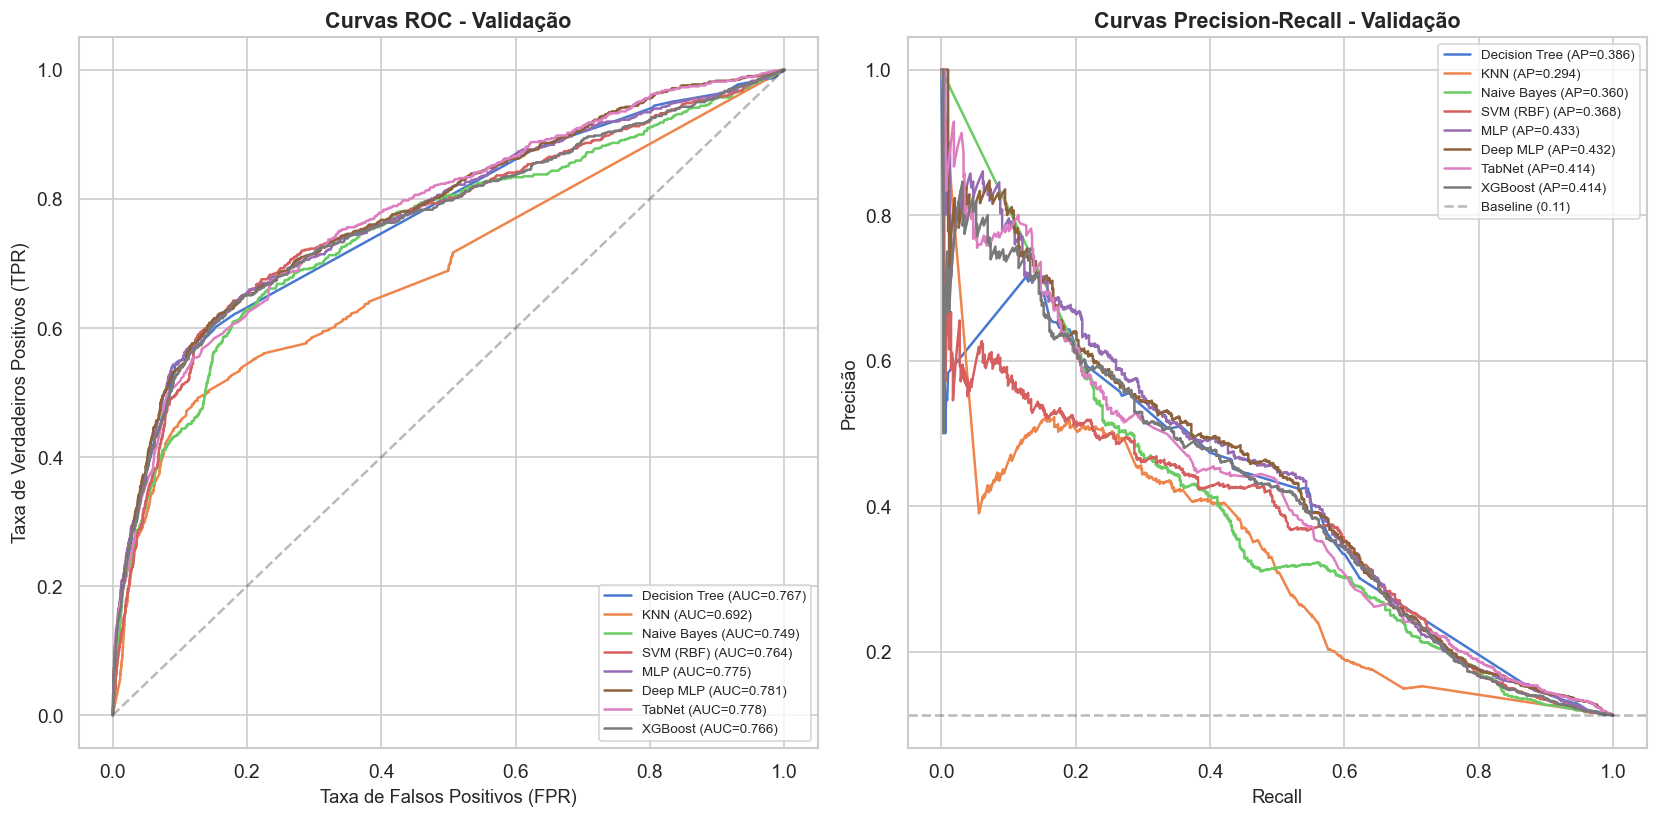

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# --- ROC ---
ax = axes[0]
for name, info in best_models.items():
    fpr, tpr, _ = roc_curve(y_val, info["y_prob_val"])
    auc = roc_auc_score(y_val, info["y_prob_val"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax.set_title("Curvas ROC - Validação", fontweight="bold")
ax.legend(fontsize=8, loc="lower right")

# --- Precision-Recall ---
ax = axes[1]
for name, info in best_models.items():
    prec, rec, _ = precision_recall_curve(y_val, info["y_prob_val"])
    ap = average_precision_score(y_val, info["y_prob_val"])
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
ax.axhline(y=y_val.mean(), color="k", linestyle="--", alpha=0.3, label=f"Baseline ({y_val.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisão")
ax.set_title("Curvas Precision-Recall - Validação", fontweight="bold")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
fig.savefig("figures/curvas_roc_val.png", dpi=150, bbox_inches="tight")
plt.show()

## Matrizes de Confusão - Top 3 Modelos

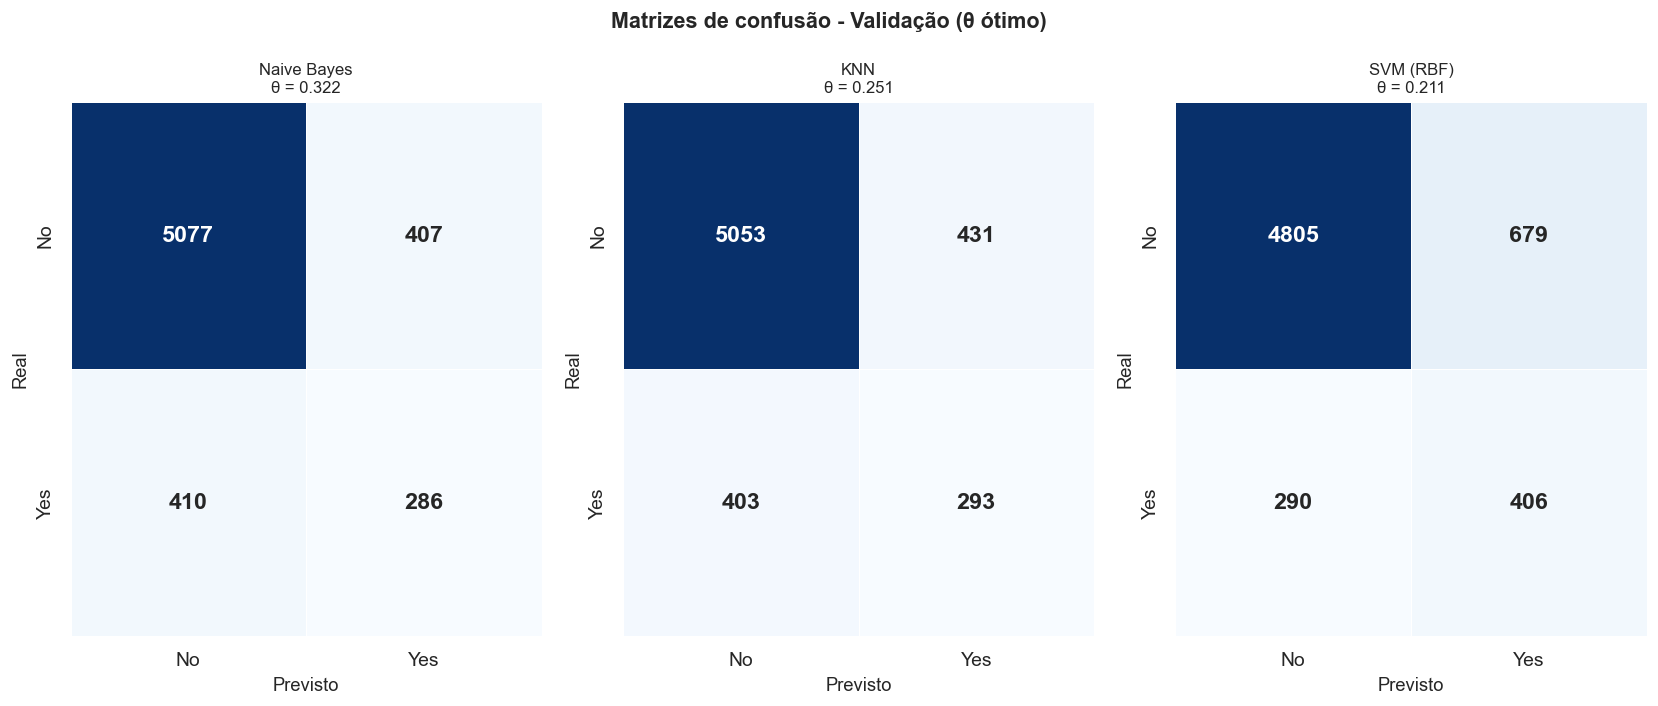

In [57]:
top3 = val_df.head(3).index.tolist()

with sns.axes_style("white"):
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))
    fig.suptitle("Matrizes de confusão - Validação (θ ótimo)",
                 fontweight="bold", fontsize=13)

    for ax, name in zip(axes, top3):
        info = best_models[name]
        y_pred = (info["y_prob_val"] >= info["threshold"]).astype(int)
        cm = confusion_matrix(y_val, y_pred)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"],
            cbar=False, ax=ax, linewidths=0.5, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"}
        )
        ax.set_title(f"{name}\nθ = {info['threshold']:.3f}", fontsize=10)
        ax.set_ylabel("Real")
        ax.set_xlabel("Previsto")

    plt.tight_layout()
    fig.savefig("figures/matrizes_conf_top3_val.png", dpi=150, bbox_inches="tight")
    plt.show()

---

# Avaliação Final (Teste)

In [61]:
test_results = []
test_preds = {}

for name, info in best_models.items():
    model = info["model"]
    thr   = info["threshold"]

    X_in = X_test.values if "TabNet" in name else X_test

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_in)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_in)
    else:
        y_prob = model.predict(X_in)

    y_pred = (y_prob >= thr).astype(int)

    test_results.append({
        "Modelo": name,
        "F1 teste":  f1_score(y_test, y_pred),
        "AUC teste": roc_auc_score(y_test, y_prob),
        "Prec":      precision_score(y_test, y_pred, zero_division=0),
        "Rec":       recall_score(y_test, y_pred),
        "θ usado":   thr,
    })
    test_preds[name] = y_pred

test_df = pd.DataFrame(test_results).set_index("Modelo").sort_values("F1 teste", ascending=True)

,F1 teste,AUC teste,Prec,Rec,θ usado
Modelo,,,,,
Naive Bayes,0.4351,0.7682,0.4470,0.4239,0.3215
KNN,0.4435,0.7190,0.4504,0.4368,0.2513
SVM (RBF),0.4872,0.7873,0.3980,0.6279,0.2110
TabNet,0.4963,0.7920,0.4710,0.5244,0.1683
XGBoost,0.5036,0.7910,0.4572,0.5603,0.6506
Deep MLP,0.5048,0.8012,0.4536,0.5690,0.2355
Decision Tree,0.5057,0.7893,0.4542,0.5704,0.6632
MLP,0.5061,0.8028,0.4566,0.5675,0.2218


## Teste de McNemar (comparação par a par dos top 4)

In [64]:
def mcnemar_test(y_true, pred_a, pred_b):
    """Testa se dois classificadores têm taxas de erro significativamente diferentes."""
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    n12 = (correct_a & ~correct_b).sum()   # A acerta, B erra
    n21 = (~correct_a & correct_b).sum()   # A erra, B acerta
    if n12 + n21 == 0:
        return 0.0, 1.0, n12, n21
    chi2 = (abs(n12 - n21) - 1)**2 / (n12 + n21)
    p = 1 - stats.chi2.cdf(chi2, df=1)
    return chi2, p, n12, n21

> Cuidado: aqui tem que ser `.tail()` pois lá em cima pomos `ascending=True`

In [71]:
top_models = test_df.tail(4).index.tolist()
mcnemar_rows = []

for i, name_a in enumerate(top_models):
    for name_b in top_models[i+1:]:
        chi2, p, n12, n21 = mcnemar_test(y_test, test_preds[name_a], test_preds[name_b])
        mcnemar_rows.append({
            "Modelo A": name_a,
            "Modelo B": name_b,
            "n12 (A✓ B✗)": n12,
            "n21 (A✗ B✓)": n21,
            "χ²": chi2,
            "p-valor": p,
            "Significativo?": "Sim" if p < 0.05 else "Não",
        })

mcnemar_df = pd.DataFrame(mcnemar_rows)

,Modelo A,Modelo B,n12 (A✓ B✗),n21 (A✗ B✓),χ²,p-valor,Significativo?
0,XGBoost,Deep MLP,108,100,0.2356,0.6274,Não
1,XGBoost,Decision Tree,108,101,0.1722,0.6781,Não
2,XGBoost,MLP,102,100,0.0050,0.9439,Não
3,Deep MLP,Decision Tree,61,62,0.0000,1.0000,Não
4,Deep MLP,MLP,19,25,0.5682,0.4510,Não
5,Decision Tree,MLP,64,69,0.1203,0.7287,Não


> Interpretação do teste de McNemar

O teste de McNemar compara **dois classificadores no mesmo conjunto de teste**. \
Constrói uma tabela 2x2 contando apenas os casos de *discordância*:

$$\chi^2 = \frac{(|n_{12} - n_{21}| - 1)^2}{n_{12} + n_{21}}$$

onde $n_{12}$ = instâncias que A acerta e B erra, $n_{21}$ = o inverso.

- $H_0$: os dois modelos têm a mesma taxa de erro (diferença não é significativa)
- Se $p < 0.05$: rejeitamos $H_0$ - os modelos são estatisticamente diferentes
- Se $p \geq 0.05$: não há evidência de diferença - modelos são equivalentes

Analisando a tabela acima podemos concluir:
- Pares sem diferença significativa ($p \geq 0.05$): modelos são intercambiáveis na prática
- Pares com diferença ($p < 0.05$): há um vencedor estatístico. **Para o top 4, não há caso**

## _Classification Report_ do Melhor Modelo

In [72]:
best_name = test_df.index[-1]
best_pred = test_preds[best_name]

print(f"=== Melhor modelo: {best_name} ===\n")
print(classification_report(y_test, best_pred, target_names=["No", "Yes"], digits=4))

=== Melhor modelo: MLP ===

              precision    recall  f1-score   support

          No     0.9434    0.9143    0.9286      5483
         Yes     0.4566    0.5675    0.5061       696

    accuracy                         0.8752      6179
   macro avg     0.7000    0.7409    0.7173      6179
weighted avg     0.8885    0.8752    0.8810      6179



---

# Salvando os Artefatos Finais

In [73]:
import os
os.makedirs("artifacts", exist_ok=True)

test_df.to_csv("artifacts/df_test_final.csv")
mcnemar_df.to_csv("artifacts/df_mcnemar.csv", index=False)
val_df.to_csv("artifacts/df_val_comparativo.csv")

# salvar modelos tunados
for name, info in tuned.items():
    safe = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    if "TabNet" not in name:
        joblib.dump(info["model"], f"artifacts/model_{safe}.joblib")

print("Artefatos de classificação salvos.")

Artefatos de classificação salvos.


---

# Conclusão

## Resultados finais

Oito classificadores foram treinados, tunados e avaliados para prever a subscrição de depósitos a prazo, \
**sem a feature `duration`** (data leakage). A tabela abaixo resume os resultados no conjunto de teste (n = 6.179):

| Modelo | F1 | AUC | Precision | Recall | θ |
|---|---|---|---|---|---|
| **MLP** | **0.5061** | **0.8028** | 0.4566 | 0.5675 | 0.2218 |
| Decision Tree | 0.5057 | 0.7893 | 0.4542 | 0.5704 | 0.6632 |
| Deep MLP | 0.5048 | 0.8012 | 0.4536 | 0.5690 | 0.2355 |
| XGBoost | 0.5036 | 0.7910 | 0.4572 | 0.5603 | 0.6506 |
| TabNet | 0.4963 | 0.7920 | **0.4710** | 0.5244 | 0.1683 |
| SVM (RBF) | 0.4872 | 0.7873 | 0.3980 | **0.6279** | 0.2110 |
| KNN | 0.4435 | 0.7190 | 0.4504 | 0.4368 | 0.2513 |
| Naive Bayes | 0.4351 | 0.7682 | 0.4470 | 0.4239 | 0.3215 |

O MLP na arquitetura `(100, 50)` é o melhor modelo com $F1 = 0.506$ e $AUC = 0.803$, superando inclusive \
o XGBoost (gradient boosting) e o TabNet (deep learning pra dados tabulares).

## Teste de McNemar

Nenhum par entre os 4 melhores modelos apresentou diferença estatisticamente significativa ($p < 0.05$). \
O par mais próximo - XGBoost vs MLP - obteve $\chi^2 = 0.005$, $p = 0.944$. Os modelos são estatisticamente \
intercambiáveis, reforçando que **o gargalo é o poder preditivo das features, não o algoritmo**.

## Achados principais

1. **O desbalanceamento 88/12 foi o desafio central.** Duas intervenções foram decisivas: \
`class_weight="balanced"` (SVM: ganho de +0.156 em F1) e otimização de threshold \
(SVM: de F1 = 0.000 em $\theta = 0.5$ para F1 = 0.487 em $\theta = 0.211$)

2. **Modelos simples tunados competem com deep learning.** A Decision Tree com poda \
(`max_depth = 7`, `class_weight = balanced`) empata com MLP, Deep MLP e XGBoost. \
TabNet e Deep MLP não trouxeram ganho sobre o MLP básico, confirmando que para dados tabulares \
com poucas features, a complexidade extra não se justifica [(Grinsztajn et al., 2022) - Why do tree-based \
models still outperform deep learning on tabular data?](https://doi.org/10.48550/arXiv.2207.08815)

3. **Impacto prático:** o melhor modelo identifica 57% dos potenciais subscritores (recall = 0.5675) \
com 46% de precisão. Comparado com ligações aleatórias (taxa de 12%), o modelo é **3.8x mais eficiente** \
($\text{precision} / \text{taxa base} = 0.46 / 0.12$)

4. **Referência ao paper original:** [Moro et al. (2014)](https://doi.org/10.1016/j.dss.2014.03.001) reportam $AUC = 0.80$ sem `duration` com o melhor \
modelo (neural network). Nosso resultado (AUC = 0.803) é consistente, validando a análise.

## Para o Agrupamento

A classificação revelou que features socioeconômicas (`euribor3m`, `emp.var.rate`, `nr.employed`) dominam a previsão, \
enquanto atributos individuais (`age`) e de campanha (`was_contacted`, `poutcome`) complementam. O notebook de agrupamento \
investigará se existem **segmentos naturais de clientes** - grupos com perfis distintos que a classificação trata homogeneamente.

# Fim